# Regression with Kernel Density Matrices

This notebook illustrates how to use [Kernel Density Matrices](https://github.com/fagonzalezo/kdm) for regression.

In [ ]:
# Uncomment to install the required packages
# !pip install git+https://github.com/fagonzalezo/kdm.git

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import optimizers

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import kdm


We will use a simple example to illustrate the main steps of the method. We will generate a synthetic dataset. We will use the mean squared error (MSE) to evaluate the performance of the model. As baseline, we will use a Gaussian Process (GP) model.

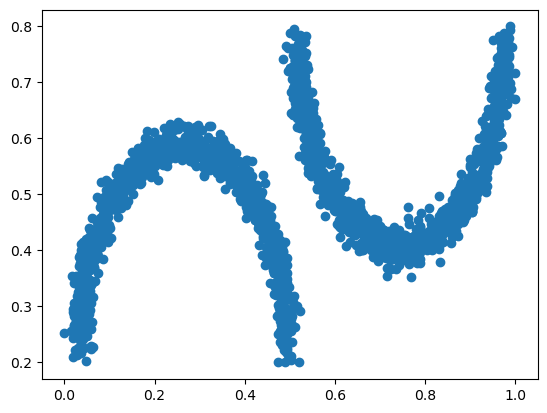

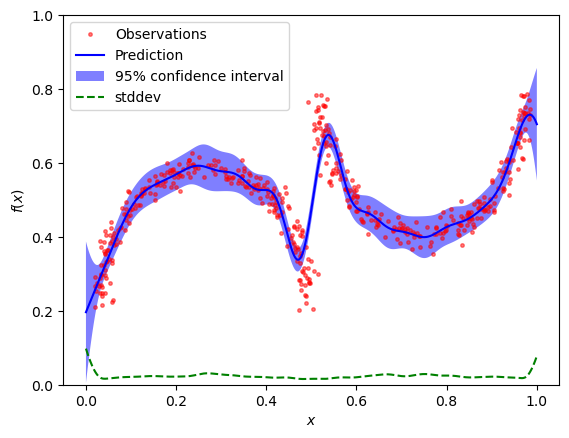

Test MSE: 0.0034650310767576505


In [4]:


np.random.seed(1)

num_train_samples = 500

# create a two moons dataset
X, y = make_moons(n_samples=2000, noise=0.05)

# move the points from class two to the right and to the top
X[y == 1, 0] += 1.1
X[y == 1, 1] += 1

y = X[:, 1:]
X = X[:, :1]

scaler = MinMaxScaler((0, 1))
X = scaler.fit_transform(X)

scaler = MinMaxScaler((0.2, 0.8))
y = scaler.fit_transform(y)

# plot the dataset
plt.scatter(X, y, label='Class 0')
plt.show()

X_train, X_test = X[:num_train_samples], X[num_train_samples:]
y_train, y_test = y[:num_train_samples], y[num_train_samples:]

# Instantiate a Gaussian Process model
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10., (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha= 0.01,# dy ** 2,
                              n_restarts_optimizer=10)

# Fit to data using Maximum Likelihood Estimation of the parameters
gp.fit(X_train, y_train)

# Make the prediction on the meshed x-axis (ask for MSE as well)
x = np.atleast_2d(np.linspace(0, 1, 1000)).T
y_pred, sigma = gp.predict(x, return_std=True)

# Plot the function, the prediction and the 95% confidence interval based on
# the MSE
plt.figure()
plt.plot(X_train.ravel(), y_train, 'r.', markersize=5, label='Observations', alpha=0.5)
plt.plot(x, y_pred, 'b-', label='Prediction')
plt.fill_between(x[:,0], y_pred - 1.9600 * sigma, y_pred + 1.9600 * sigma,
         alpha=.5, fc='b', ec='None', label='95% confidence interval')

plt.plot(x[:,0], sigma, 'g--', label='stddev')

plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.ylim(0, 1)
plt.legend(loc='upper left')

plt.show()
y_pred_test = gp.predict(X_test)

print(f"Test MSE: {mean_squared_error(y_test, y_pred_test)}")

We define functions to train a KDM regression model and to plot and evaluate the results.

In [5]:
from kdm.models import KDMRegressModel
from kdm.utils import dm_rbf_expectation, dm_rbf_variance

def train_model(n_comp=20, generative=False, epochs=1000):
    encoded_size = 1
    dim_y = 1
    encoder = keras.layers.Identity()

    kdm_reg_model = KDMRegressModel(encoded_size=encoded_size,
                                dim_y=dim_y,
                                encoder=encoder,
                                n_comp=n_comp,
                                sigma_x=0.1,
                                sigma_y=0.1,
                                generative=generative)


    # train the model
    kdm_reg_model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                        loss=None)
    out1= kdm_reg_model(X_train[:10])

    idx = np.random.randint(X_train.shape[0], size=n_comp)
    kdm_reg_model.init_components(X_train[idx], 
                            y_train[idx],
                            init_sigma=True)


    # Make a for to do one training step and print some loss and sigma 
    # values
    losses = []
    sigma_x = []
    sigma_y = []
    for i in range(epochs):
        history = kdm_reg_model.fit(X_train, y_train, epochs=1, batch_size=32, verbose=0)
        losses.append(history.history['loss'][0])
        sigma_x.append(kdm_reg_model.kernel.sigma.numpy())
        sigma_y.append(kdm_reg_model.sigma_y.numpy())

    plt.plot(losses)
    plt.title("Loss")
    plt.show()
    plt.plot(sigma_x)
    plt.title("Sigma X")
    plt.show()
    plt.plot(sigma_y)
    plt.title("Sigma Y")
    plt.show()
    return kdm_reg_model

def plot_model(kdm_model):
    # Make the prediction on the meshed x-axis (ask for MSE as well)
    rho_y = kdm_model.predict(x)
    y_pred = dm_rbf_expectation(rho_y).numpy().flatten()
    y_var = keras.ops.convert_to_numpy(dm_rbf_variance(rho_y, kdm_model.sigma_y))

    # Plot the function, the prediction and the 95% confidence interval based on
    # the MSE
    plt.figure()
    plt.plot(X_train.ravel(), y_train, 'r.', markersize=5, label='Observations', alpha=0.5)
    plt.plot(x, y_pred, 'b-', label='Prediction')

    stddev = y_var ** 0.5
    plt.fill_between(x[:,0], y_pred - 1.9600 * stddev, y_pred + 1.9600 * stddev,
            alpha=.5, fc='b', ec='None', label='95% confidence interval')
    plt.plot(x[:,0], stddev, 'g--', label='stddev')
    # plot kdm components as yellow stars
    c_x = keras.ops.convert_to_numpy(kdm_model.kdm.c_x)
    c_y = keras.ops.convert_to_numpy(kdm_model.kdm.c_y)
    c_w = keras.ops.convert_to_numpy(kdm_model.kdm.c_w)
    c_w = np.abs(c_w) / np.sum(np.abs(c_w))
    plt.scatter(c_x, c_y, s=c_w*2000, c='y', marker='o', label='KDM components')

    plt.xlabel('$x$')
    plt.ylabel('$f(x)$')
    plt.ylim(0, 1)
    plt.legend(loc='upper left')

    plt.show()
    rho_y = kdm_model.predict(X_test)
    y_pred_test = dm_rbf_expectation(rho_y)
    from sklearn.metrics import mean_squared_error

    print(f"Test MSE: {mean_squared_error(y_test, y_pred_test)}")
    print(f"X_sigma: {kdm_model.kernel.sigma.numpy() / np.sqrt(2)}")
    print(f"Y_sigma: {kdm_model.sigma_y.numpy() / np.sqrt(2)}")
    print(f"Avg variance: {np.mean(y_var)}")


First, we train a discriminative KDM regression model with 20 components.

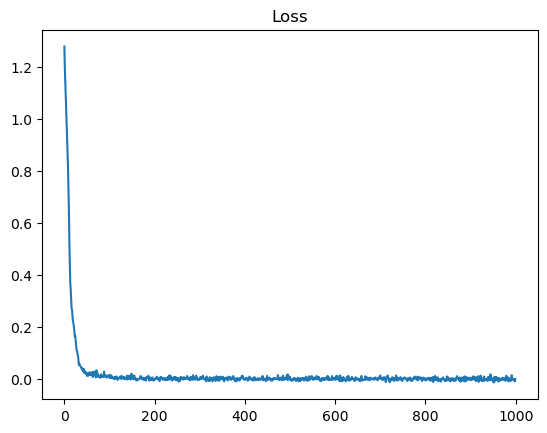

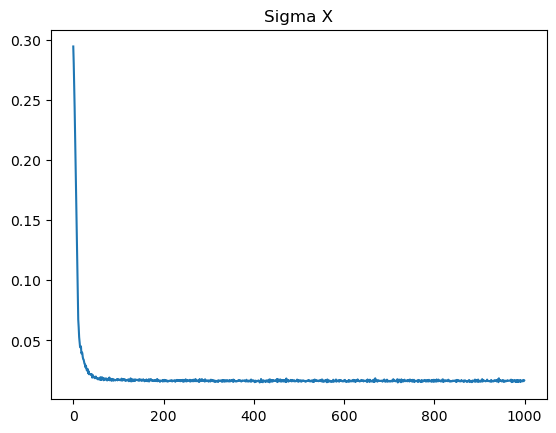

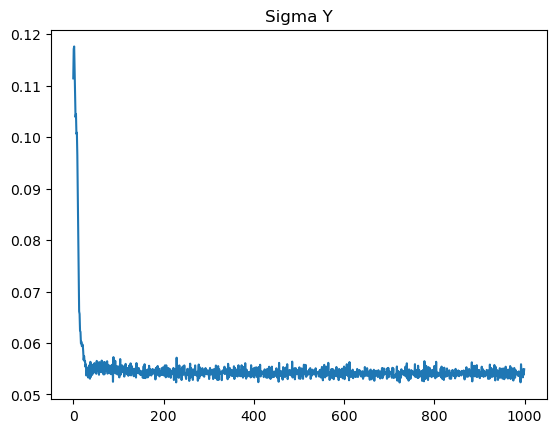

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 452us/step


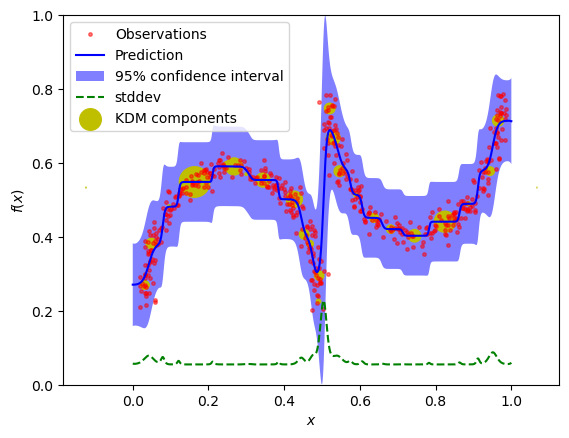

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 398us/step
Test MSE: 0.002915441823242688
X_sigma: 0.011795031314707553
Y_sigma: 0.0388069188664702
Avg variance: 0.004451422486454248


In [10]:
kdm_reg_model = train_model(n_comp=30, generative=False, epochs=1000)
plot_model(kdm_reg_model)

Next, we train a generative KDM regression model with 20 components.


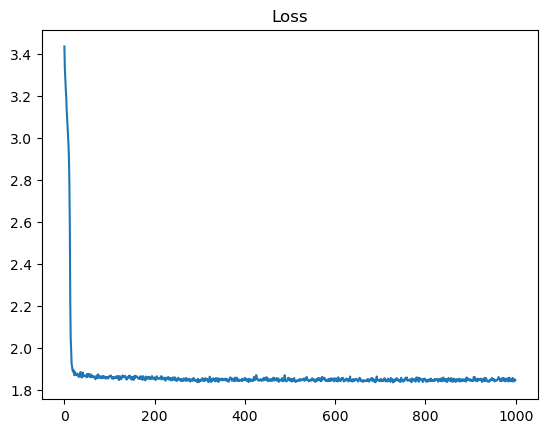

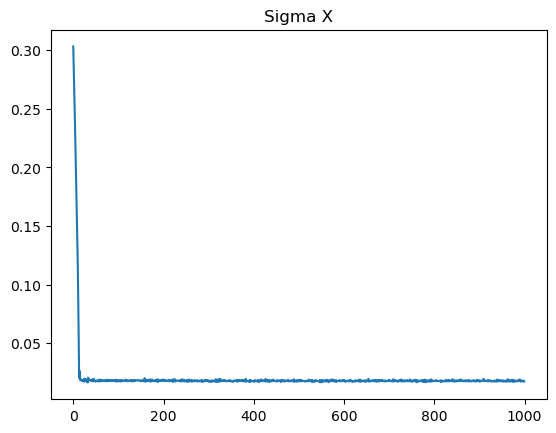

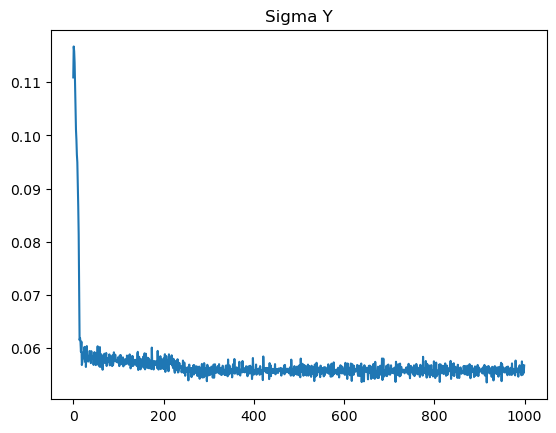

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step


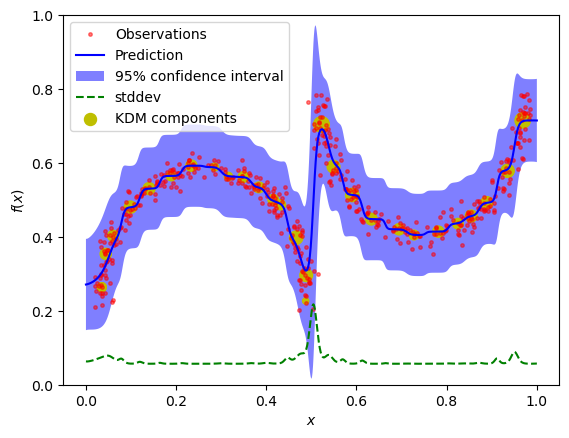

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 503us/step
Test MSE: 0.00286445950802821
X_sigma: 0.01226590907716142
Y_sigma: 0.040102599917570134
Avg variance: 0.004524328280240297


In [11]:
kdm_reg_model = train_model(n_comp=30, generative=True, epochs=1000)
plot_model(kdm_reg_model)

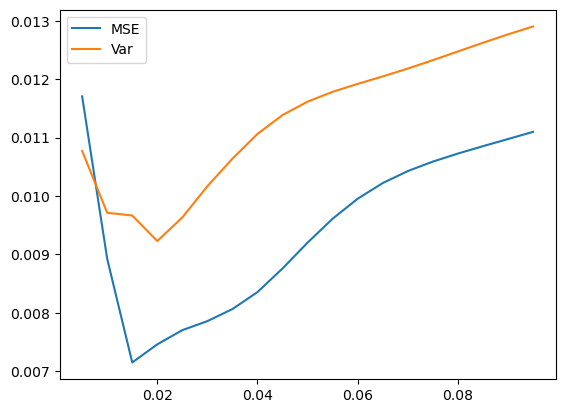

In [96]:
# make a copy of kdm_reg_model
kdm_copy = KDMRegressModel(encoded_size=encoded_size,
                            dim_y=dim_y,
                            encoder=encoder,
                            n_comp=n_comp,
                            sigma_x=0.1,
                            sigma_y=0.1,
                            generative=1,
                            entropy_reg_x=0.0)

kdm_copy.set_weights(kdm_reg_model.get_weights())

mses = []
vars = []
sigmas = np.arange(0.005, 0.1, 0.005)
for sigma in sigmas:
    kdm_copy.kernel.sigma.assign(sigma * np.sqrt(2))
    # rho_y = kdm_model.predict(x)
    rho_y = kdm_copy.predict(X_test, verbose=0)
    y_pred = keras.ops.convert_to_numpy(dm_rbf_expectation(rho_y)).flatten()
    y_var = keras.ops.convert_to_numpy(dm_rbf_variance(rho_y, kdm_copy.sigma_y))
    y_pred_test = dm_rbf_expectation(rho_y)
    mses.append(mean_squared_error(y_test, y_pred_test))
    vars.append(np.mean(y_var))

plt.plot(sigmas, mses, label="MSE")
plt.plot(sigmas, vars, label="Var")
plt.legend()
plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


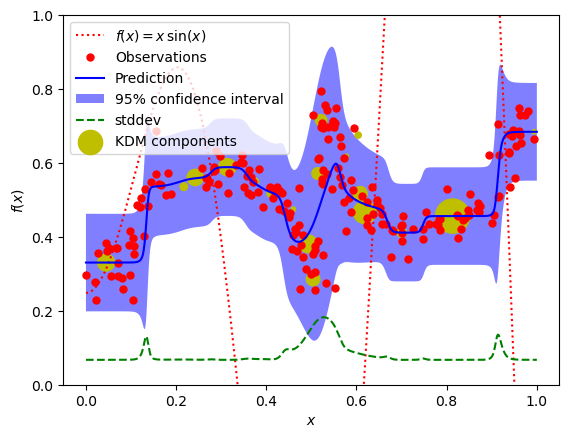

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step
Test MSE: 0.007458023409519097
X_sigma: 0.019999999341613214
Y_sigma: 0.04758799084858226
Avg variance: 0.007333896588534117


In [97]:

# Make the prediction on the meshed x-axis (ask for MSE as well)
sigma = sigmas[np.argmin(vars)]
kdm_copy.kernel.sigma.assign(sigma * np.sqrt(2))
plot_model(kdm_copy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


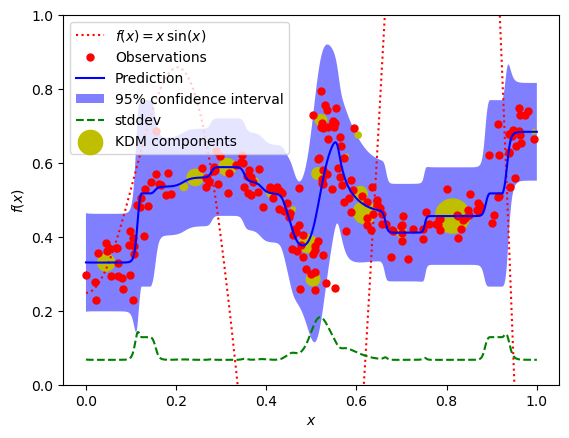

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step
Test MSE: 0.007147253074143629
X_sigma: 0.015000000164754418
Y_sigma: 0.04758799084858226
Avg variance: 0.007641222793608904


In [98]:
# Make the prediction on the meshed x-axis (ask for MSE as well)
sigma = sigmas[np.argmin(mses)]
kdm_copy.kernel.sigma.assign(sigma * np.sqrt(2))
plot_model(kdm_copy)

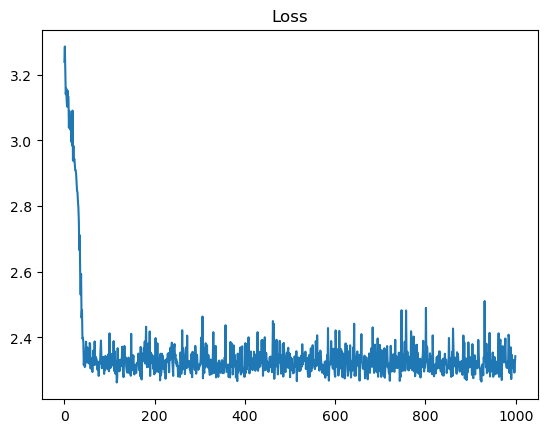

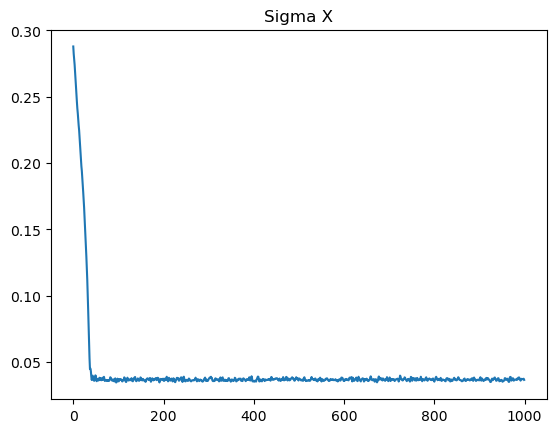

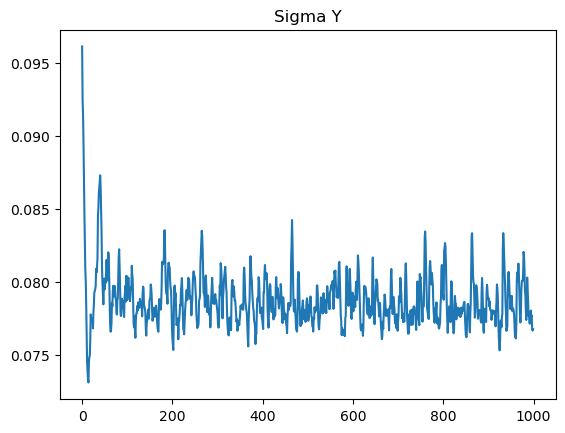

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step


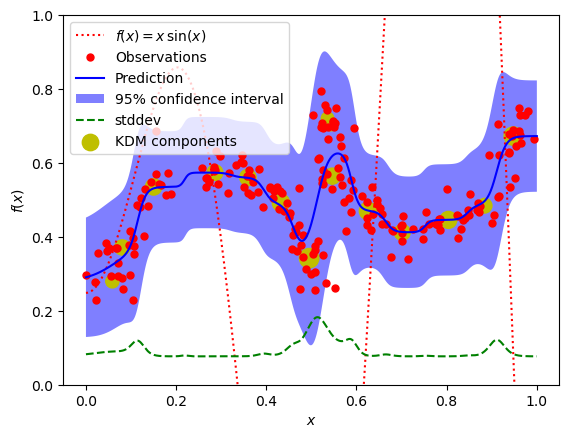

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step
Test MSE: 0.0063698391149372416
X_sigma: 0.025801676358175755
Y_sigma: 0.05429145764095208
Avg variance: 0.008968652226030827


In [99]:
kdm_reg_model = train_model(n_comp=15, generative=True, epochs=1000)
plot_model(kdm_reg_model)